# nb08 — внутридневной масштаб: 15m / 30m бары

Из nb06: отношение edge/кост монотонно улучшается к короткому концу шкалы
(0.21 / 0.09 / 0.03 / −0.02 при окне формации 3 / 7 / 14 / 30 дней), а кривая
отклика показала, что сам возврат живёт на горизонте **1–12 часов**, а не недель.
Но там мы стояли на часовых барах и не мерили ничего плотнее.

Пользователь: «давай минутки посмотрим, можно либо на них сигналы либо собрать
пол часа / 15 минут». Панель на 15m собрана (`panel_close_15min.parquet`).

**Что здесь обязательно сделать до всяких выводов.** На коротких горизонтах
появляется эффект, которого нет на дневках: цена последней сделки прыгает между
bid и ask. Это создаёт **отрицательную автокорреляцию доходностей**, которая
выглядит как возврат к среднему, но торговать её нельзя — чтобы её «поймать»,
надо покупать по ask и продавать по bid, то есть отдавать ровно тот спред,
который её и создаёт. Поэтому §1 — измерение микроструктурного шума, и только
после него мы имеем право смотреть на сигнал.

Меняем **только таймфрейм**: те же 43 ликвидных символа, тот же TRAIN, тот же
ежедневный рефит ADF, тот же движок (`_engine.py`).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px1h = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px1h.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])

px15 = load_panel("close", "15min")[liq]
print(f"панель 15m: {px15.shape[0]} баров x {px15.shape[1]} символов, "
      f"NaN {px15.isna().values.mean()*100:.4f}%")

# санити: 15m-бар, закрывающий час, должен совпадать с часовым закрытием
h_end = px15.index[px15.index.minute == 45]
common = h_end.floor("h").intersection(px1h.index)
a = px15.loc[px15.index.minute == 45].set_index(px15.index[px15.index.minute == 45].floor("h"))
diff = (a.loc[common, liq] - px1h.loc[common, liq]).abs().values
print(f"сверка 15m vs 1h на границах часа: max |разница| = {np.nanmax(diff):.10f}")

PAIRS = [((x, y) if daily_m[x] <= daily_m[y] else (y, x)) for x, y in combinations(liq, 2)]
LP15 = np.log(px15.loc[TRAIN[0]:TRAIN[1]]).iloc[:-1]
bk15 = Book(LP15, liq, PAIRS)
COST = ROUND_TRIP_BPS / 100
MAKER = 2 * (0.0 + 3.0) / 100      # maker 0 bps + 3 bps проскальзывания на сторону
print(f"\nbk15: {len(bk15.index)} баров по {bk15.bar_min}м, {bk15.bars_per_day} бар/день, "
      f"{len(bk15.PAIRS)} пар")
print(f"косты: taker round-trip {COST*100:.1f} bps, гипотетический maker {MAKER*100:.1f} bps")

панель 15m: 81696 баров x 43 символов, NaN 0.0000%
сверка 15m vs 1h на границах часа: max |разница| = 0.0000000000

bk15: 52607 баров по 15м, 96 бар/день, 903 пар
косты: taker round-trip 21.0 bps, гипотетический maker 6.0 bps


## 1. Микроструктурный контроль: сколько «возврата» — это отскок цены между bid и ask

Мера — автокорреляция доходностей на лаге 1. У честного случайного блуждания она
0. Если последняя сделка прыгает bid↔ask, соседние доходности систематически
противоположны и автокорреляция **отрицательна**; классический результат Roll:
для чистого bounce она равна −0.5, а половина спреда восстанавливается как
`2·sqrt(-cov1)`.

Это ровно та величина, которую нельзя торговать. Меряем её на 1m, 5m, 15m, 1h —
и смотрим, на каком масштабе она рассасывается.

сырьё 1m: 132480 баров x 10 символов (2024-06-01 00:00:00+00:00 .. 2024-08-31 23:59:00+00:00)



АВТОКОРРЕЛЯЦИЯ ДОХОДНОСТЕЙ НА ЛАГЕ 1 (10 ликвидных символов, 3 месяца)
   TF  минут  ac(1) медиана  ac(1) мин  ac(1) макс  симв. с ac<0  Roll полспреда, bps  σ бара, bps
 1min      1         -0.014     -0.028       0.002             9                 1.11         12.0
 5min      5         -0.039     -0.059       0.002             9                 6.21         27.3
15min     15         -0.036     -0.075       0.013             9                 9.26         46.4
   1h     60          0.009     -0.057       0.027             4                12.35         87.4

как читать: ac(1) сильно отрицательная = шум отскока, он даёт ЛОЖНЫЙ возврат.
'Roll полспреда' — во что этот шум пересчитывается как половина спреда;
сравните с нашим допущением о проскальзывании 5.0 bps на сторону.

АВТОКОРРЕЛЯЦИЯ ИЗМЕНЕНИЙ СПРЕДА (β из OLS на всём отрезке, 45 пар из выборки)


   TF  ac(1) спреда, медиана  доля пар с ac<0  доля var от отскока, %
 1min                 -0.046            100.0                     9.3
 5min                 -0.038             93.3                     7.7
15min                 -0.034             82.2                     6.8
   1h                  0.015             42.2                    -3.0

'доля var от отскока': в модели 'случайное блуждание + iid шум' имеем
ac1 = -f/2, где f — доля дисперсии изменений спреда от шума. Значит f = -2·ac1;
при чистом отскоке ac1 = -0.5 и f = 100%. Эта часть дисперсии
неторгуема: чем f выше, тем сильнее σ формации надута шумом и тем меньше
реального хода стоит за каждой σ.
[saved] notebooks\statarb\_out\nb08_micro.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb08_micro.png')

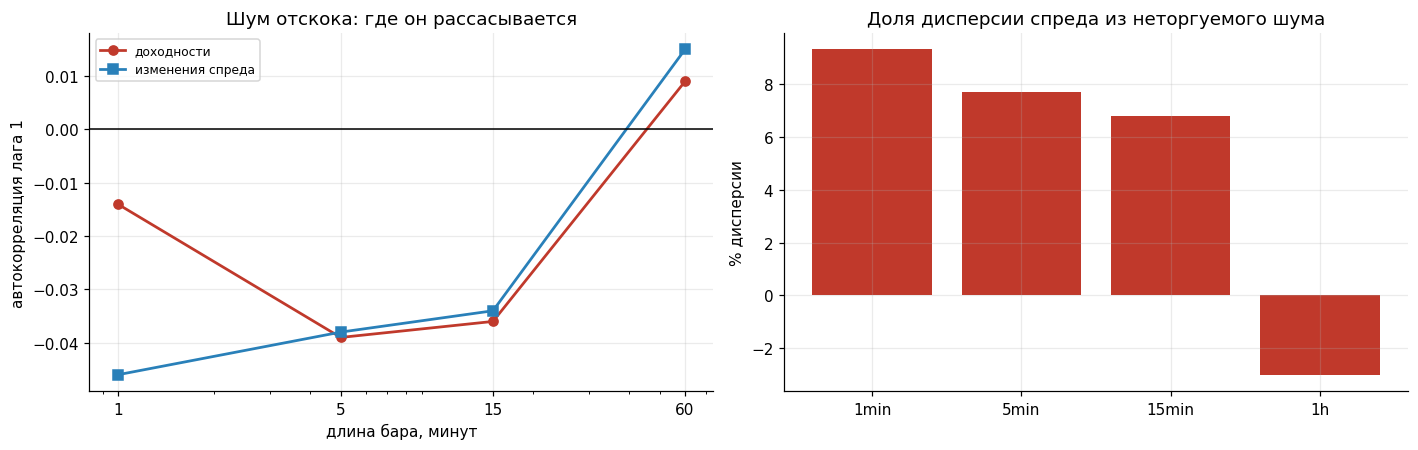

In [2]:
SAMPLE = liq[:10]
raw = {s: loader.load(s, "2024-06-01", "2024-09-01", "1min")["close"] for s in SAMPLE}
raw = pd.DataFrame(raw).dropna()
print(f"сырьё 1m: {raw.shape[0]} баров x {raw.shape[1]} символов "
      f"({raw.index[0]} .. {raw.index[-1]})")

rows = []
for tf, minutes in [("1min", 1), ("5min", 5), ("15min", 15), ("1h", 60)]:
    p = raw if tf == "1min" else raw.resample(tf).last()
    r = np.log(p).diff().dropna()
    ac1 = np.array([r[s].autocorr(1) for s in SAMPLE])
    # оценка Roll: половина спреда = sqrt(-cov1), если cov1<0
    cov1 = np.array([np.cov(r[s].values[:-1], r[s].values[1:])[0, 1] for s in SAMPLE])
    half_bps = np.where(cov1 < 0, np.sqrt(np.maximum(-cov1, 0))*1e4, np.nan)
    rows.append({"TF": tf, "минут": minutes,
                 "ac(1) медиана": round(float(np.median(ac1)), 3),
                 "ac(1) мин": round(float(ac1.min()), 3),
                 "ac(1) макс": round(float(ac1.max()), 3),
                 "симв. с ac<0": int((ac1 < 0).sum()),
                 "Roll полспреда, bps": round(float(np.nanmedian(half_bps)), 2),
                 "σ бара, bps": round(float(np.median(r.std())*1e4), 1)})
AC = pd.DataFrame(rows)
print("\nАВТОКОРРЕЛЯЦИЯ ДОХОДНОСТЕЙ НА ЛАГЕ 1 (10 ликвидных символов, 3 месяца)")
print(AC.to_string(index=False))
print()
print("как читать: ac(1) сильно отрицательная = шум отскока, он даёт ЛОЖНЫЙ возврат.")
print("'Roll полспреда' — во что этот шум пересчитывается как половина спреда;")
print("сравните с нашим допущением о проскальзывании 5.0 bps на сторону.")

# то же для СПРЕДА пары — именно его мы торгуем
print("\nАВТОКОРРЕЛЯЦИЯ ИЗМЕНЕНИЙ СПРЕДА (β из OLS на всём отрезке, 45 пар из выборки)")
rows2 = []
for tf in ["1min", "5min", "15min", "1h"]:
    p = raw if tf == "1min" else raw.resample(tf).last()
    lp = np.log(p)
    acs = []
    for x, y in combinations(SAMPLE, 2):
        xv, yv = lp[x].values, lp[y].values
        b = np.cov(xv, yv)[0, 1] / np.var(xv)
        s = pd.Series(yv - b * xv).diff().dropna()
        acs.append(s.autocorr(1))
    acs = np.array(acs)
    rows2.append({"TF": tf, "ac(1) спреда, медиана": round(float(np.median(acs)), 3),
                  "доля пар с ac<0": round(float((acs < 0).mean())*100, 1),
                  "доля var от отскока, %": round(float(np.median(-2*acs))*100, 1)})
ACS = pd.DataFrame(rows2)
print(ACS.to_string(index=False))
print()
print("'доля var от отскока': в модели 'случайное блуждание + iid шум' имеем")
print("ac1 = -f/2, где f — доля дисперсии изменений спреда от шума. Значит f = -2·ac1;")
print("при чистом отскоке ac1 = -0.5 и f = 100%. Эта часть дисперсии")
print("неторгуема: чем f выше, тем сильнее σ формации надута шумом и тем меньше")
print("реального хода стоит за каждой σ.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(AC["минут"], AC["ac(1) медиана"], "o-", lw=1.8, color="#c0392b", label="доходности")
ax[0].plot([1, 5, 15, 60], ACS["ac(1) спреда, медиана"], "s-", lw=1.8,
           color="#2980b9", label="изменения спреда")
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xscale("log"); ax[0].set_xticks([1, 5, 15, 60]); ax[0].set_xticklabels([1, 5, 15, 60])
ax[0].set_xlabel("длина бара, минут"); ax[0].set_ylabel("автокорреляция лага 1")
ax[0].set_title("Шум отскока: где он рассасывается"); ax[0].legend(fontsize=8)
ax[1].bar(range(4), ACS["доля var от отскока, %"], color="#c0392b")
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(ACS.TF)
ax[1].set_ylabel("% дисперсии"); ax[1].set_title("Доля дисперсии спреда из неторгуемого шума")
show("nb08_micro")

## 2. Рефит на 15m барах

Окна формации теперь считаем в барах: 0.5 дня = 48 баров, 1 день = 96, и так далее.
Порог ADF калибруется заново для каждой длины окна — критическое значение зависит
от числа наблюдений, поэтому переносить порог с часового масштаба нельзя.

Отдельно проверяем **частоту рефита**: раз в день (как у пользователя) против
4 раз в день. На окне 0.5–1 день суточный рефит означает, что к концу дня
параметры устарели на столько же, сколько длится само окно.

In [3]:
LDAYS = [0.5, 1, 2, 3, 7]
R15, THR15 = {}, {}
for L in LDAYS:
    n = bk15.nbars(L)
    t0 = time.time()
    THR15[L] = calibrate_thr(bk15, n, reps=10)
    R15[L] = refit(bk15, n, THR15[L])
    sel = R15[L].sel
    print(f"L={L:>3}д = {n:>4} баров: порог t={THR15[L]:.3f}, рефитов {len(R15[L].ends)}, "
          f"отобрано {sel.sum(axis=1).mean():.0f} пар/рефит ({sel.mean()*100:.1f}%), "
          f"{time.time()-t0:.0f}s")

# σ спреда отобранных пар — масштаб, с которым сравнивается фиксированный кост
print("\nМАСШТАБ ХОДА: σ спреда отобранных пар против фиксированного коста")
rows = []
for L in LDAYS:
    R = R15[L]
    g = 1 + np.abs(R.B)
    sd_pct = (R.SD / g * 100)[R.sel]
    m = float(np.median(sd_pct))
    rows.append({"L, дн": L, "σ спреда, % gross": round(m, 3),
                 "кост taker в σ": round(COST/m, 2), "кост maker в σ": round(MAKER/m, 2),
                 "кост/ход 1.5σ, %": round(COST/(1.5*m)*100, 1)})
SC = pd.DataFrame(rows)
print(SC.to_string(index=False))
print()
print("сравнение с часовыми барами (nb06): при L=3д σ была 0.54% -> кост 0.39σ,")
print("при L=7д σ была 0.79% -> кост 0.27σ. Короткое окно = маленькая σ = кост")
print("занимает БОЛЬШУЮ долю хода. Это работает против нас, и edge должен расти")
print("быстрее, чтобы это перебить.")

L=0.5д =   48 баров: порог t=-3.538, рефитов 548, отобрано 68 пар/рефит (7.5%), 12s


L=  1д =   96 баров: порог t=-3.364, рефитов 548, отобрано 95 пар/рефит (10.5%), 12s


L=  2д =  192 баров: порог t=-3.288, рефитов 547, отобрано 104 пар/рефит (11.5%), 13s


L=  3д =  288 баров: порог t=-3.435, рефитов 546, отобрано 82 пар/рефит (9.1%), 13s


L=  7д =  672 баров: порог t=-3.486, рефитов 542, отобрано 80 пар/рефит (8.9%), 13s

МАСШТАБ ХОДА: σ спреда отобранных пар против фиксированного коста
 L, дн  σ спреда, % gross  кост taker в σ  кост maker в σ  кост/ход 1.5σ, %
   0.5              0.216            0.97            0.28              64.7
   1.0              0.300            0.70            0.20              46.6
   2.0              0.423            0.50            0.14              33.1
   3.0              0.501            0.42            0.12              27.9
   7.0              0.757            0.28            0.08              18.5

сравнение с часовыми барами (nb06): при L=3д σ была 0.54% -> кост 0.39σ,
при L=7д σ была 0.79% -> кост 0.27σ. Короткое окно = маленькая σ = кост
занимает БОЛЬШУЮ долю хода. Это работает против нас, и edge должен расти
быстрее, чтобы это перебить.


## 3. Кривая отклика на 15m: где живёт возврат и сколько он стоит в bps

Главное измерение, без правил и порогов: где был `z` — куда пошёл спред. β
заморожена на баре замера (иначе получим фантомные десятки σ — ловушка,
встретившаяся уже трижды).

Горизонты берём от 15 минут до суток. Рядом — синтетика на перемешанных
доходностях: она показывает, сколько отклика создаёт сам метод измерения.

И сразу переводим в **bps**, потому что именно там происходит сравнение с костом:
`edge_bps = сила_возврата_в_σ × σ_спреда_в_%_gross × 100`.

L=0.5д посчитан (σ спреда 0.216% gross)


L=1д посчитан (σ спреда 0.300% gross)


L=3д посчитан (σ спреда 0.501% gross)

СИЛА ВОЗВРАТА НА 15m БАРАХ, реальность против синтетики
 L, дн горизонт  реальность σ  синтетика σ  разница σ  edge, bps  кост taker bps  edge/кост  edge/maker
   0.5      15м        0.0027      -0.0035     0.0062       0.13            21.0      0.006       0.022
   0.5      30м        0.0009      -0.0061     0.0069       0.15            21.0      0.007       0.025
   0.5       1ч       -0.0053      -0.0111     0.0059       0.13            21.0      0.006       0.021
   0.5       2ч       -0.0240      -0.0205    -0.0035      -0.08            21.0     -0.004      -0.013
   0.5       4ч       -0.0382      -0.0534     0.0152       0.33            21.0      0.016       0.055
   0.5      12ч       -0.0579      -0.1654     0.1075       2.33            21.0      0.111       0.388
   0.5      24ч       -0.0887      -0.3141     0.2254       4.88            21.0      0.232       0.813
   1.0      15м        0.0032       0.0006     0.0026       0.08         

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb08_response.png')

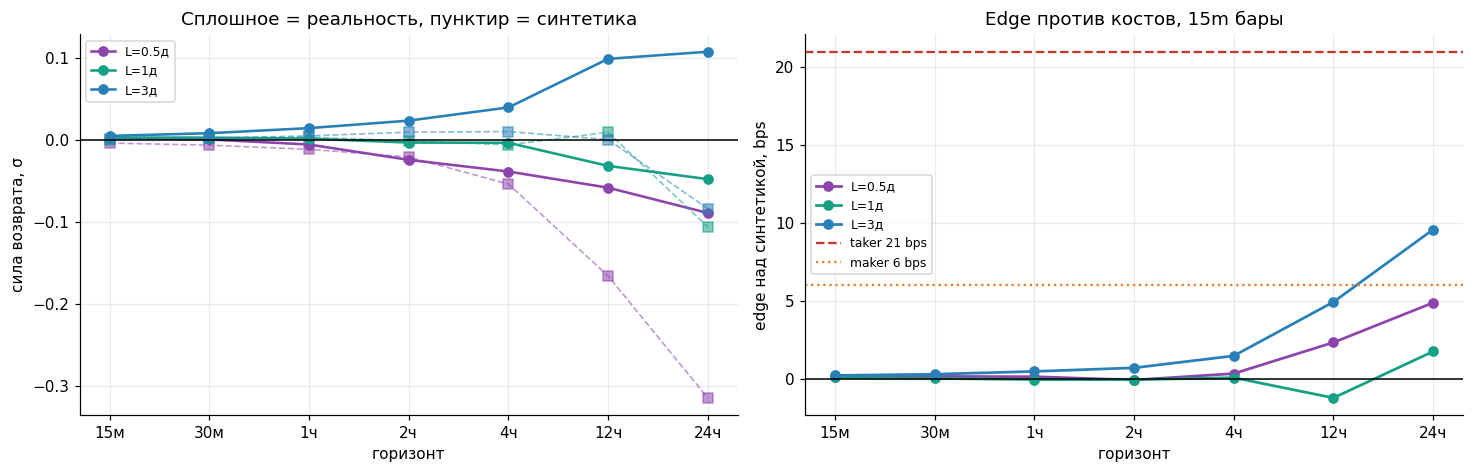

In [4]:
ZB = np.array([-np.inf, -4, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 4, np.inf])
HB = [1, 2, 4, 8, 16, 48, 96]        # баров: 15м, 30м, 1ч, 2ч, 4ч, 12ч, 24ч
HLAB = ["15м", "30м", "1ч", "2ч", "4ч", "12ч", "24ч"]

bk15n = bk15.with_panel(shuffled(bk15.M, seed=99))
R15N = {}
rows = []
for L in [0.5, 1, 3]:
    n = bk15.nbars(L)
    R15N[L] = refit(bk15n, n, calibrate_thr(bk15n, n, reps=10))
    mr, nr = response(bk15, R15[L], HB, ZB)
    mn, _ = response(bk15n, R15N[L], HB, ZB)
    pr, pn = pull(mr, ZB), pull(mn, ZB)
    g = 1 + np.abs(R15[L].B)
    sd_pct = float(np.median((R15[L].SD / g * 100)[R15[L].sel]))
    for k, h in enumerate(HB):
        rows.append({"L, дн": L, "горизонт": HLAB[k],
                     "реальность σ": round(pr[k], 4), "синтетика σ": round(pn[k], 4),
                     "разница σ": round(pr[k]-pn[k], 4),
                     "edge, bps": round((pr[k]-pn[k])*sd_pct*100, 2),
                     "кост taker bps": round(COST*100, 1),
                     "edge/кост": round((pr[k]-pn[k])*sd_pct*100/(COST*100), 3),
                     "edge/maker": round((pr[k]-pn[k])*sd_pct*100/(MAKER*100), 3)})
    print(f"L={L}д посчитан (σ спреда {sd_pct:.3f}% gross)")
RS = pd.DataFrame(rows)
print("\nСИЛА ВОЗВРАТА НА 15m БАРАХ, реальность против синтетики")
print(RS.to_string(index=False))
print()
print("для сравнения — часовые бары nb06 (L=7д): максимум разницы +0.069σ на 12ч,")
print("что при σ=0.79% давало 5.5 bps против коста 21 bps (edge/кост 0.26).")
print()
best = RS.sort_values("edge, bps", ascending=False).head(5)
print("ЛУЧШИЕ ЯЧЕЙКИ ПО edge В BPS:")
print(best.to_string(index=False))
print()
if (RS["edge/кост"] > 1).any():
    print("!! есть ячейки, где edge превышает taker-кост:")
    print(RS[RS["edge/кост"] > 1].to_string(index=False))
else:
    print(f"ни на одном горизонте edge не превышает taker-кост 21 bps "
          f"(максимум {RS['edge/кост'].max():.2f} от коста)")
if (RS["edge/maker"] > 1).any():
    print(f"\nпри maker-косте {MAKER*100:.0f} bps положительных ячеек: "
          f"{(RS['edge/maker']>1).sum()} из {len(RS)}")
    print(RS[RS["edge/maker"] > 1][["L, дн", "горизонт", "edge, bps", "edge/maker"]].to_string(index=False))
else:
    print(f"\nдаже при maker-косте {MAKER*100:.0f} bps ни одна ячейка не выходит в плюс")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))
for L, c in [(0.5, "#8e44ad"), (1, "#16a085"), (3, "#2980b9")]:
    d = RS[RS["L, дн"] == L]
    ax[0].plot(range(len(HB)), d["реальность σ"], "o-", lw=1.7, color=c, label=f"L={L}д")
    ax[0].plot(range(len(HB)), d["синтетика σ"], "s--", lw=1.1, alpha=0.55, color=c)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xticks(range(len(HB))); ax[0].set_xticklabels(HLAB)
ax[0].set_xlabel("горизонт"); ax[0].set_ylabel("сила возврата, σ")
ax[0].set_title("Сплошное = реальность, пунктир = синтетика"); ax[0].legend(fontsize=8)
for L, c in [(0.5, "#8e44ad"), (1, "#16a085"), (3, "#2980b9")]:
    d = RS[RS["L, дн"] == L]
    ax[1].plot(range(len(HB)), d["edge, bps"], "o-", lw=1.8, color=c, label=f"L={L}д")
ax[1].axhline(COST*100, color="#c0392b", ls="--", lw=1.5, label="taker 21 bps")
ax[1].axhline(MAKER*100, color="#e67e22", ls=":", lw=1.5, label=f"maker {MAKER*100:.0f} bps")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xticks(range(len(HB))); ax[1].set_xticklabels(HLAB)
ax[1].set_xlabel("горизонт"); ax[1].set_ylabel("edge над синтетикой, bps")
ax[1].set_title("Edge против костов, 15m бары"); ax[1].legend(fontsize=8)
show("nb08_response")

## 4. Проверка на подмену: реальный edge не должен зависеть от длины бара

Если возврат на горизонте 4 часа настоящий, он должен измеряться одинаково хоть
15-минутными барами, хоть часовыми — мы же смотрим на один и тот же ход цены за
одни и те же 4 часа. Если же «edge» раздувается при мелких барах, значит мы мерим
не рынок, а шум дискретизации.

Считаем одну и ту же силу возврата на горизонте 4ч и 12ч, но на панелях 15m, 30m
и 1h, при одинаковом окне формации в **календарных** днях.

In [5]:
px30 = px15.resample("30min").last()
LP30 = np.log(px30.loc[TRAIN[0]:TRAIN[1]]).iloc[:-1]
bk30 = Book(LP30, liq, PAIRS)
LP1h = np.log(px1h.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
bk1h = Book(LP1h, liq, PAIRS)
print(f"bk30: {len(bk30.index)} баров по {bk30.bar_min}м; "
      f"bk1h: {len(bk1h.index)} баров по {bk1h.bar_min}м")

rows = []
for bkx, tag in [(bk15, "15m"), (bk30, "30m"), (bk1h, "1h")]:
    L = 1.0
    n = bkx.nbars(L)
    R = refit(bkx, n, calibrate_thr(bkx, n, reps=10))
    bkn = bkx.with_panel(shuffled(bkx.M, seed=99))
    Rn = refit(bkn, n, calibrate_thr(bkn, n, reps=10))
    hb = [max(int(round(h*60/bkx.bar_min)), 1) for h in (1, 4, 12)]
    # only_selected=False: при равном КАЛЕНДАРНОМ окне число наблюдений у 15m/30m/1h
    # разное (96/48/24), поэтому мощность ADF разная и отбор сам стал бы фактором.
    # Убираем отбор целиком — тогда сравниваются именно бары.
    mr, _ = response(bkx, R, hb, ZB, only_selected=False)
    mn, _ = response(bkn, Rn, hb, ZB, only_selected=False)
    pr, pn = pull(mr, ZB), pull(mn, ZB)
    g = 1 + np.abs(R.B)
    sd_pct = float(np.median(R.SD / g * 100))
    for k, h in enumerate((1, 4, 12)):
        rows.append({"бар": tag, "горизонт, ч": h, "баров в горизонте": hb[k],
                     "σ формации, % gross": round(sd_pct, 3),
                     "реальность σ": round(pr[k], 4), "синтетика σ": round(pn[k], 4),
                     "разница σ": round(pr[k]-pn[k], 4),
                     "edge, bps": round((pr[k]-pn[k])*sd_pct*100, 2)})
    print(f"{tag} готов")
BR = pd.DataFrame(rows)
print("\nОДИН И ТОТ ЖЕ ГОРИЗОНТ, РАЗНАЯ ДЛИНА БАРА (окно формации 1 день)")
print(BR.to_string(index=False))
print()
for h in (1, 4, 12):
    d = BR[BR["горизонт, ч"] == h]
    sp = d["edge, bps"].max() - d["edge, bps"].min()
    print(f"горизонт {h}ч: edge {list(d['edge, bps'])} bps по барам "
          f"{list(d['бар'])}, разброс {sp:.2f} bps")
print()
print("если edge на одном горизонте сильно зависит от длины бара — доверять нужно")
print("самой КРУПНОЙ дискретизации: она наименее заражена шумом отскока.")

bk30: 26303 баров по 30м; bk1h: 13151 баров по 60м


15m готов


30m готов


1h готов

ОДИН И ТОТ ЖЕ ГОРИЗОНТ, РАЗНАЯ ДЛИНА БАРА (окно формации 1 день)
бар  горизонт, ч  баров в горизонте  σ формации, % gross  реальность σ  синтетика σ  разница σ  edge, bps
15m            1                  4                0.497       -0.0048      -0.0024    -0.0024      -0.12
15m            4                 16                0.497       -0.0176      -0.0078    -0.0098      -0.49
15m           12                 48                0.497       -0.0389      -0.0139    -0.0250      -1.24
30m            1                  2                0.495       -0.0046      -0.0022    -0.0024      -0.12
30m            4                  8                0.495       -0.0163      -0.0104    -0.0058      -0.29
30m           12                 24                0.495       -0.0369      -0.0244    -0.0125      -0.62
 1h            1                  1                0.490       -0.0047       0.0005    -0.0052      -0.25
 1h            4                  4                0.490       -0.0145      -

## 5. Свип с правилом на 15m барах

Теперь то же, что nb06, но на внутридневном масштабе: окна формации 0.5–7 дней,
ежедневный рефит, вход 2σ / выход 0.5σ / стоп 4σ, лимит удержания 2·L. Считаем
gross (что дал спред) и net при двух уровнях костов.

In [6]:
rows = []
SW15 = {}
for L in LDAYS:
    t0 = time.time()
    d = sweep(bk15, R15[L], "REFIT", cost_pct=COST)
    SW15[L] = d
    if not len(d):
        continue
    bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()
    rows.append({"L, дн": L, "сделок": len(d),
                 "GROSS %": round(d.gross.mean(), 4),
                 "NET taker %": round(d.pnl.mean(), 4),
                 "NET maker %": round(d.gross.mean() - MAKER, 4),
                 "% плюс gross": round((d.gross > 0).mean()*100, 1),
                 "медиана ч": round(float(d.hours.median()), 2),
                 "ср. σ хода": round(d.sigma.mean(), 3),
                 "мес + (net)": f"{(bym>0).sum()}/{len(bym)}",
                 "сек": round(time.time()-t0)})
SW = pd.DataFrame(rows)
print("СВИП НА 15m БАРАХ (TRAIN)")
print(SW.to_string(index=False))
print()
print(f"для сравнения nb06 на часовых барах: GROSS +0.045% (L=3д), +0.018% (7д);")
print(f"NET taker −0.165% и −0.192%.")
print()
if (SW["NET maker %"] > 0).any():
    print("ячейки, положительные при maker-косте:")
    print(SW[SW["NET maker %"] > 0][["L, дн", "сделок", "GROSS %", "NET maker %"]].to_string(index=False))
else:
    print("ни одна ячейка не положительна даже при maker-косте")
print()
print("СКОЛЬКО СДЕЛОК В ГОД И ЧЕГО ЭТО СТОИТ (портфельный масштаб):")
years = (bk15.index[-1] - bk15.index[0]).days / 365.25
for _, r in SW.iterrows():
    n_yr = r["сделок"] / years
    print(f"  L={r['L, дн']:>3}д: {n_yr:>7.0f} сделок/год на 903 пары "
          f"= {n_yr/903:>5.1f} на пару; если брать каждый сигнал по 2% gross, "
          f"кост {n_yr*0.02*COST:>6.1f}% капитала/год "
          f"(taker) против {n_yr*0.02*MAKER:>5.1f}% (maker)")
print("(это 'если брать всё'; лимит суммарного gross <= 100% отсечёт часть сигналов —")
print(" сколько именно, мерил nb04: одновременных позиций там доходило до 154)")

C:\Users\nvisary\AppData\Local\Temp\ipykernel_17880\1127166925.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_17880\1127166925.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_17880\1127166925.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_17880\1127166925.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


СВИП НА 15m БАРАХ (TRAIN)
 L, дн  сделок  GROSS %  NET taker %  NET maker %  % плюс gross  медиана ч  ср. σ хода мес + (net)  сек
   0.5  182492   0.0004      -0.2096      -0.0596          34.7       1.00      -0.016        0/19    4
   1.0  205127   0.0019      -0.2081      -0.0581          35.2       1.25       0.001        0/19    4
   2.0  156401  -0.0086      -0.2186      -0.0686          36.6       2.00      -0.015        0/19    3
   3.0   98865   0.0272      -0.1828      -0.0328          39.3       2.75       0.034        0/19    2
   7.0   50895  -0.0031      -0.2131      -0.0631          42.4       5.25       0.018        0/19    1

для сравнения nb06 на часовых барах: GROSS +0.045% (L=3д), +0.018% (7д);
NET taker −0.165% и −0.192%.

ни одна ячейка не положительна даже при maker-косте

СКОЛЬКО СДЕЛОК В ГОД И ЧЕГО ЭТО СТОИТ (портфельный масштаб):
  L=0.5д:  121856 сделок/год на 903 пары = 134.9 на пару; если брать каждый сигнал по 2% gross, кост  511.8% капитала/год (taker) пр

C:\Users\nvisary\AppData\Local\Temp\ipykernel_17880\1127166925.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


## 6. Итог

In [7]:
print("ЧТО ИЗМЕРЕНО НА ВНУТРИДНЕВНОМ МАСШТАБЕ\n")
print("1. МИКРОСТРУКТУРА")
for _, r in AC.iterrows():
    print(f"   {r['TF']:>6}: ac(1) доходностей {r['ac(1) медиана']:+.3f}, "
          f"Roll полспреда {r['Roll полспреда, bps']:.2f} bps")
print()
print("2. ОТКЛИК (15m бары)")
top = RS.sort_values("edge, bps", ascending=False).iloc[0]
print(f"   максимум edge над синтетикой: {top['edge, bps']:.2f} bps "
      f"(L={top['L, дн']}д, горизонт {top['горизонт']})")
print(f"   это {top['edge/кост']:.2f} от taker-коста и {top['edge/maker']:.2f} от maker-коста")
print()
print("3. ЗАВИСИМОСТЬ ОТ ДЛИНЫ БАРА (горизонт 4ч, окно 1д)")
d4 = BR[BR["горизонт, ч"] == 4]
for _, r in d4.iterrows():
    print(f"   бар {r['бар']:>4}: edge {r['edge, bps']:+.2f} bps")
print()
print("4. СВИП С ПРАВИЛОМ")
for _, r in SW.iterrows():
    print(f"   L={r['L, дн']:>3}д: gross {r['GROSS %']:+.4f}%, "
          f"net taker {r['NET taker %']:+.4f}%, net maker {r['NET maker %']:+.4f}%, "
          f"медиана {r['медиана ч']:.1f}ч")

ЧТО ИЗМЕРЕНО НА ВНУТРИДНЕВНОМ МАСШТАБЕ

1. МИКРОСТРУКТУРА
     1min: ac(1) доходностей -0.014, Roll полспреда 1.11 bps
     5min: ac(1) доходностей -0.039, Roll полспреда 6.21 bps
    15min: ac(1) доходностей -0.036, Roll полспреда 9.26 bps
       1h: ac(1) доходностей +0.009, Roll полспреда 12.35 bps

2. ОТКЛИК (15m бары)
   максимум edge над синтетикой: 9.58 bps (L=3.0д, горизонт 24ч)
   это 0.46 от taker-коста и 1.60 от maker-коста

3. ЗАВИСИМОСТЬ ОТ ДЛИНЫ БАРА (горизонт 4ч, окно 1д)
   бар  15m: edge -0.49 bps
   бар  30m: edge -0.29 bps
   бар   1h: edge -0.60 bps

4. СВИП С ПРАВИЛОМ
   L=0.5д: gross +0.0004%, net taker -0.2096%, net maker -0.0596%, медиана 1.0ч
   L=1.0д: gross +0.0019%, net taker -0.2081%, net maker -0.0581%, медиана 1.2ч
   L=2.0д: gross -0.0086%, net taker -0.2186%, net maker -0.0686%, медиана 2.0ч
   L=3.0д: gross +0.0272%, net taker -0.1828%, net maker -0.0328%, медиана 2.8ч
   L=7.0д: gross -0.0031%, net taker -0.2131%, net maker -0.0631%, медиана 5.2ч
